<a href="https://colab.research.google.com/github/Ravi-ranjan1801/Data-Warehousing-Mining-Lab/blob/main/DWM_Lab_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import squarify

from pandas.plotting import parallel_coordinates
from scipy.stats import skew, probplot

In [8]:
df = pd.read_csv("superstore.csv", encoding="latin1")


In [9]:
df.head()
df.shape
df.columns
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


#**Q1 — Boxplot & Five-Number Summary**

In [10]:
profit = df['Profit']

minimum = profit.min()
q1 = profit.quantile(0.25)
median = profit.median()
q3 = profit.quantile(0.75)
maximum = profit.max()

iqr = q3 - q1

print("Minimum :", minimum)
print("Q1      :", q1)
print("Median  :", median)
print("Q3      :", q3)
print("Maximum :", maximum)
print("IQR     :", iqr)

Minimum : -6599.978
Q1      : 1.72875
Median  : 8.6665
Q3      : 29.364
Maximum : 8399.976
IQR     : 27.63525


In [11]:
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print("Lower Bound:", lower)
print("Upper Bound:", upper)

Lower Bound: -39.724125
Upper Bound: 70.816875


In [13]:
outliers = df[(profit < lower) | (profit > upper)]

print("Number of outliers:", len(outliers))

Number of outliers: 1881


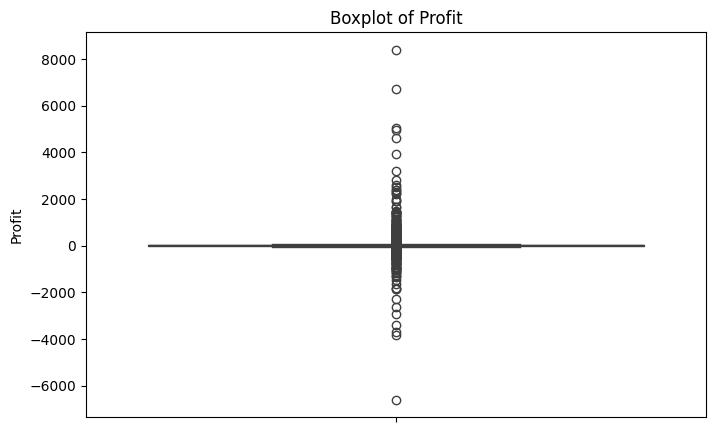

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(y=df['Profit'])
plt.title("Boxplot of Profit")
plt.ylabel("Profit")
plt.show()

#**Q2 — 3-D Boxplot**

In [15]:
df['Sales_Bin'] = pd.qcut(
    df['Sales'],
    q=5,
    labels=['S1', 'S2', 'S3', 'S4', 'S5']
)

In [17]:
df['Quantity_Bin'] = pd.qcut(
    df['Quantity'],
    q=5,
    labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5']
)

In [18]:
print(df['Sales_Bin'].value_counts().sort_index())
print(df['Quantity_Bin'].value_counts().sort_index())

Sales_Bin
S1    2000
S2    1999
S3    1997
S4    2000
S5    1998
Name: count, dtype: int64
Quantity_Bin
Q1    3301
Q2    2409
Q3    1191
Q4    1230
Q5    1863
Name: count, dtype: int64


In [19]:
groups = []

for s in df['Sales_Bin'].cat.categories:
    for q in df['Quantity_Bin'].cat.categories:
        values = df[
            (df['Sales_Bin'] == s) &
            (df['Quantity_Bin'] == q)
        ]['Profit'].dropna()

        if len(values) > 0:
            groups.append({
                'Sales_Bin': s,
                'Quantity_Bin': q,
                'Profit': values
            })

In [20]:
spread_results = []

for item in groups:
    values = item['Profit']

    spread_results.append({
        'Sales_Bin': item['Sales_Bin'],
        'Quantity_Bin': item['Quantity_Bin'],
        'Q1': values.quantile(0.25),
        'Q3': values.quantile(0.75),
        'IQR': values.quantile(0.75) - values.quantile(0.25)
    })

spread_df = pd.DataFrame(spread_results)

print(spread_df.sort_values('IQR', ascending=False).head())

   Sales_Bin Quantity_Bin        Q1        Q3        IQR
24        S5           Q5   9.59465  219.5530  209.95835
23        S5           Q4  -8.07750  197.3530  205.43050
22        S5           Q3   0.00000  143.9968  143.99680
21        S5           Q2   0.00000  142.1781  142.17810
20        S5           Q1  23.44700  140.3960  116.94900


#**Q3 — Histogram of Sales**

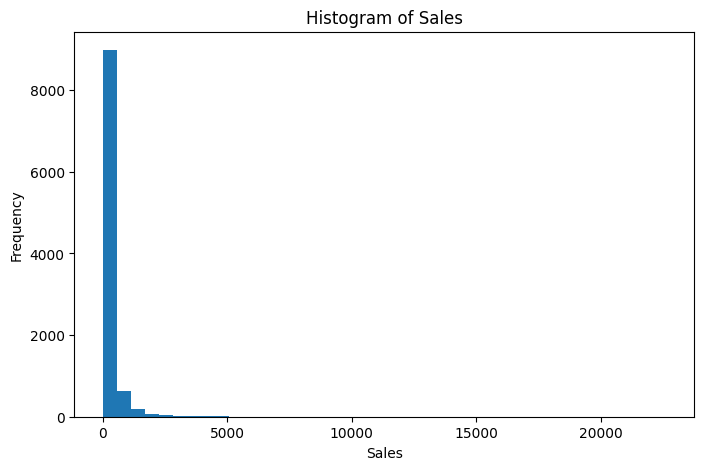

In [21]:
plt.figure(figsize=(8, 5))

plt.hist(df['Sales'], bins=40)

plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.title("Histogram of Sales")

plt.show()

In [22]:
sales_skewness = df['Sales'].skew()

print("Skewness:", sales_skewness)

Skewness: 12.97275234181623


#**Q4 — Quantile Plot**

In [23]:
sales_sorted = np.sort(df['Sales'].dropna())

In [24]:
n = len(sales_sorted)

f = np.arange(1, n + 1) / n

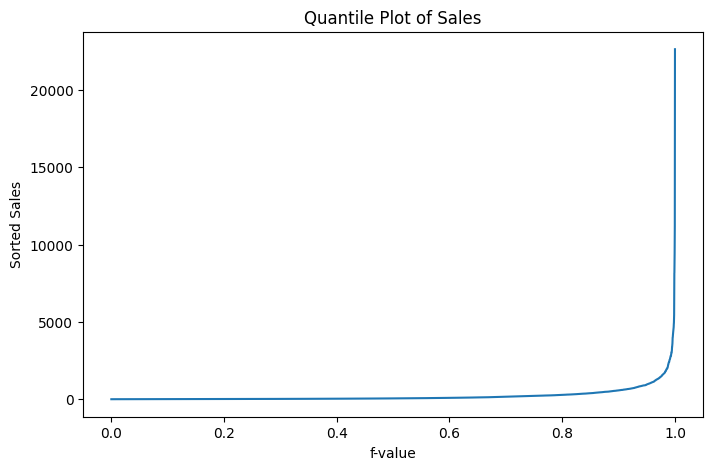

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(f, sales_sorted)

plt.xlabel("f-value")
plt.ylabel("Sorted Sales")
plt.title("Quantile Plot of Sales")

plt.show()

In [26]:
median_sales = df['Sales'].median()

print("Median Sales:", median_sales)

Median Sales: 54.489999999999995


In [28]:
percentage_below_100 = (df['Sales'] < 100).mean() * 100

print("Percentage below $100:", percentage_below_100)

Percentage below $100: 62.29737842705624


#**Q5 — Q-Q Plot: East vs West**

In [29]:
east = df[df['Region'] == 'East']['Profit'].dropna()
west = df[df['Region'] == 'West']['Profit'].dropna()

In [30]:
east_sorted = np.sort(east)
west_sorted = np.sort(west)

In [31]:
q = np.linspace(0, 1, 100)

east_q = np.quantile(east, q)
west_q = np.quantile(west, q)

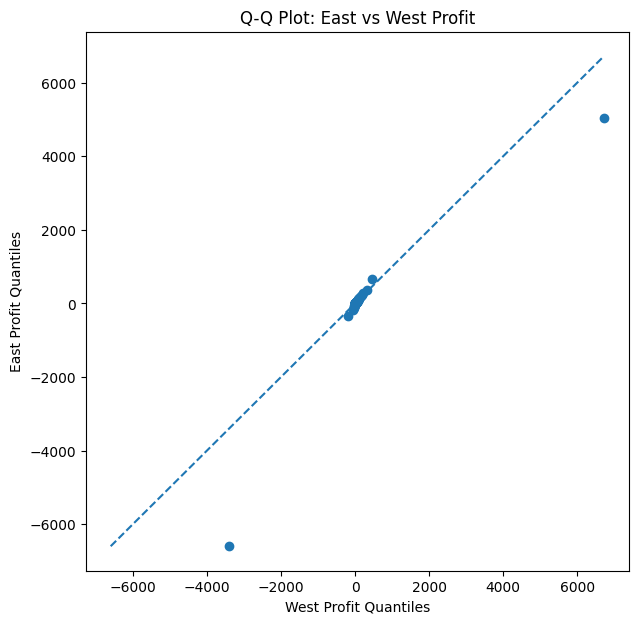

In [32]:
plt.figure(figsize=(7, 7))

plt.scatter(west_q, east_q)

minimum = min(west_q.min(), east_q.min())
maximum = max(west_q.max(), east_q.max())

plt.plot([minimum, maximum], [minimum, maximum], '--')

plt.xlabel("West Profit Quantiles")
plt.ylabel("East Profit Quantiles")
plt.title("Q-Q Plot: East vs West Profit")

plt.show()

In [33]:
east_median = east.median()
west_median = west.median()

print("East median:", east_median)
print("West median:", west_median)
print("Difference:", east_median - west_median)

East median: 8.171700000000001
West median: 11.1664
Difference: -2.994699999999998


#**Q6 — Scatter Plot & Correlation**

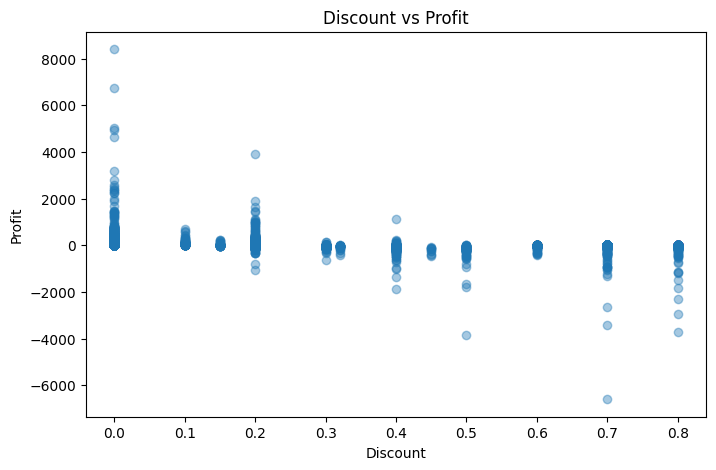

In [34]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Discount'],
    df['Profit'],
    alpha=0.4
)

plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Discount vs Profit")

plt.show()

In [35]:
correlation = df['Discount'].corr(df['Profit'])

print("Pearson correlation:", correlation)

Pearson correlation: -0.21948745637176803


In [36]:
print(df[['Discount', 'Profit']].corr())

          Discount    Profit
Discount  1.000000 -0.219487
Profit   -0.219487  1.000000


#**Q7 — Pixel-Oriented Visualization**

In [37]:
pixel_df = df[
    ['Sales', 'Quantity', 'Discount', 'Profit']
].sort_values('Sales').reset_index(drop=True)

In [38]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

normalized = scaler.fit_transform(pixel_df)

normalized_df = pd.DataFrame(
    normalized,
    columns=['Sales', 'Quantity', 'Discount', 'Profit']
)

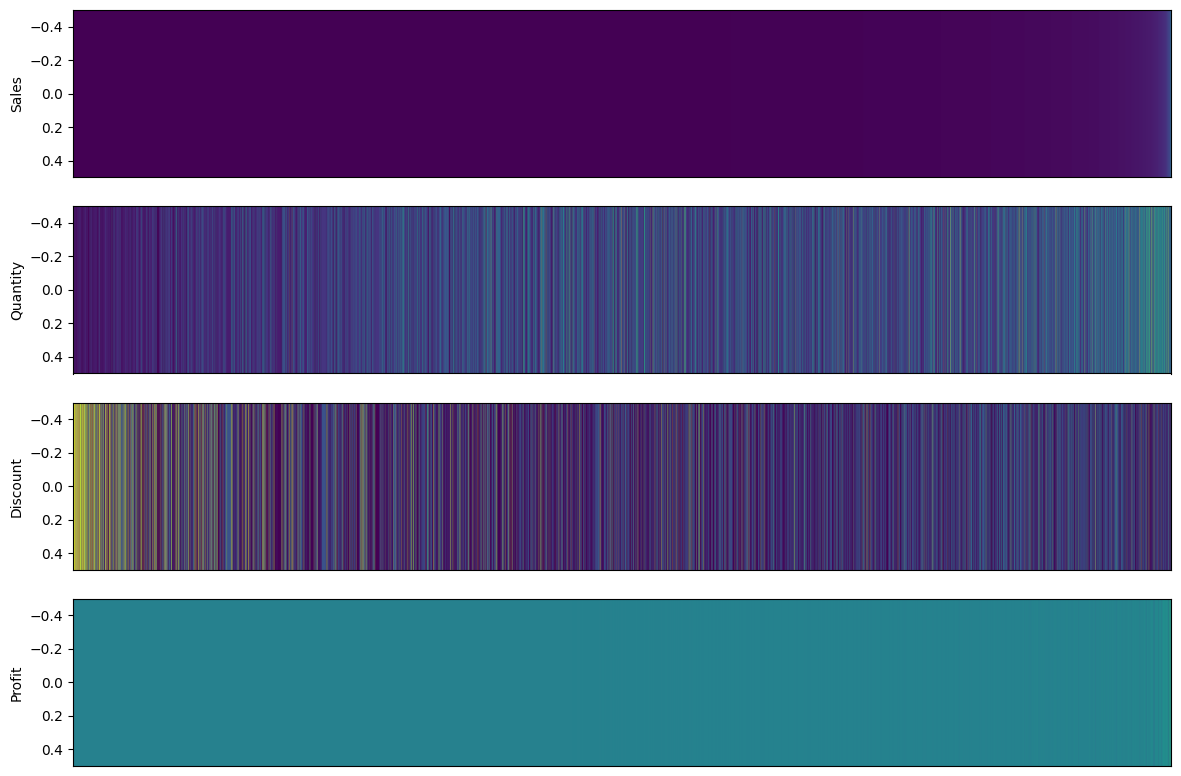

In [39]:
fig, axes = plt.subplots(4, 1, figsize=(12, 8))

attributes = ['Sales', 'Quantity', 'Discount', 'Profit']

for i, attr in enumerate(attributes):
    axes[i].imshow(
        normalized_df[[attr]].T,
        aspect='auto'
    )
    axes[i].set_ylabel(attr)
    axes[i].set_xticks([])

plt.tight_layout()
plt.show()

#**Q8 — Parallel Coordinates**

In [40]:
parallel_df = df[
    ['Sales', 'Quantity', 'Discount', 'Profit', 'Category']
].copy()

In [41]:
features = ['Sales', 'Quantity', 'Discount', 'Profit']

parallel_df[features] = MinMaxScaler().fit_transform(
    parallel_df[features]
)

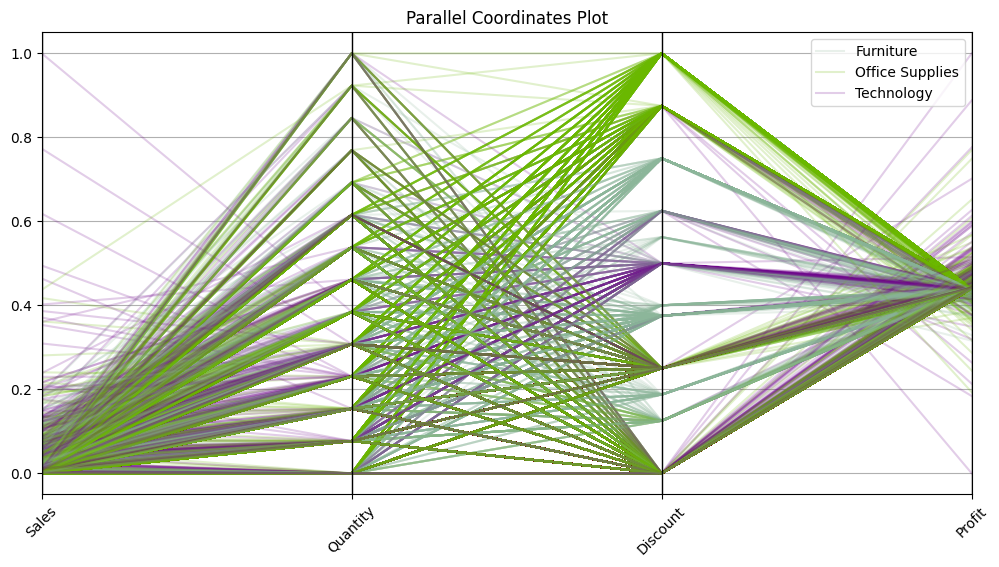

In [42]:
plt.figure(figsize=(12, 6))

parallel_coordinates(
    parallel_df,
    'Category',
    alpha=0.2
)

plt.title("Parallel Coordinates Plot")
plt.xticks(rotation=45)

plt.show()

#**Q9 — Chernoff Faces**

In [48]:
ch = df.groupby('Sub-Category')[[
    'Sales', 'Quantity', 'Discount', 'Profit'
]].mean()

print(ch)


                    Sales  Quantity  Discount      Profit
Sub-Category                                             
Accessories    215.974604  3.840000  0.078452   54.111788
Appliances     230.755710  3.710300  0.166524   38.922758
Art             34.068834  3.768844  0.074874    8.200737
Binders        133.560560  3.922521  0.372292   19.843574
Bookcases      503.859633  3.807018  0.211140  -15.230509
Chairs         532.332420  3.818476  0.170178   43.095894
Copiers       2198.941618  3.441176  0.161765  817.909190
Envelopes       64.867724  3.566929  0.080315   27.418019
Fasteners       13.936774  4.211982  0.082028    4.375660
Furnishings     95.825668  3.723093  0.138349   13.645918
Labels          34.303055  3.846154  0.068681   15.236962
Machines      1645.553313  3.826087  0.306087   29.432669
Paper           57.284092  3.779562  0.074891   24.856620
Phones         371.211534  3.699663  0.154556   50.073938
Storage        264.590553  3.732861  0.074704   25.152277
Supplies      

In [49]:
ch_norm = pd.DataFrame(
    MinMaxScaler().fit_transform(ch),
    index=ch.index,
    columns=ch.columns
)

#**Q10 — Dimensional Stacking / Heatmap**

In [50]:
heatmap_data = df.pivot_table(
    values='Profit',
    index='Region',
    columns='Category',
    aggfunc='mean'
)

print(heatmap_data)

Category  Furniture  Office Supplies  Technology
Region                                          
Central   -5.968918         6.244712   80.231981
East       5.068496        23.957114   88.714084
South     20.395199        20.086827   68.231506
West      16.272914        27.733183   73.962687


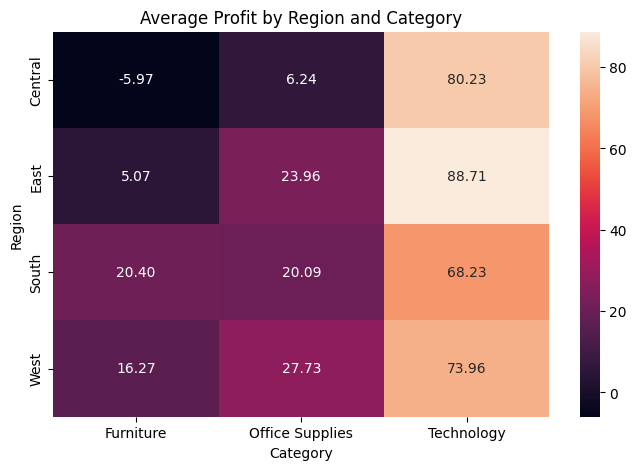

In [51]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.2f'
)

plt.title("Average Profit by Region and Category")
plt.xlabel("Category")
plt.ylabel("Region")

plt.show()

In [52]:
minimum_region = heatmap_data.stack().idxmin()
minimum_profit = heatmap_data.stack().min()

print("Lowest combination:", minimum_region)
print("Lowest average profit:", minimum_profit)

Lowest combination: ('Central', 'Furniture')
Lowest average profit: -5.968917671517671


#**Q11 — Tree Map**

In [55]:
treemap_data = df.groupby(
    'Sub-Category'
)['Sales'].sum().sort_values(ascending=False)

print(treemap_data)


Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91705.1640
Paper           78479.2060
Supplies        46673.5380
Art             27118.7920
Envelopes       16476.4020
Labels          12486.3120
Fasteners        3024.2800
Name: Sales, dtype: float64


In [56]:
top3 = treemap_data.head(3)

print(top3)

Sub-Category
Phones     330007.054
Chairs     328449.103
Storage    223843.608
Name: Sales, dtype: float64


In [57]:
total_sales = df['Sales'].sum()

top3_percentage = top3.sum() / total_sales * 100

print("Top 3 sales percentage:", top3_percentage)

Top 3 sales percentage: 38.407602062484735


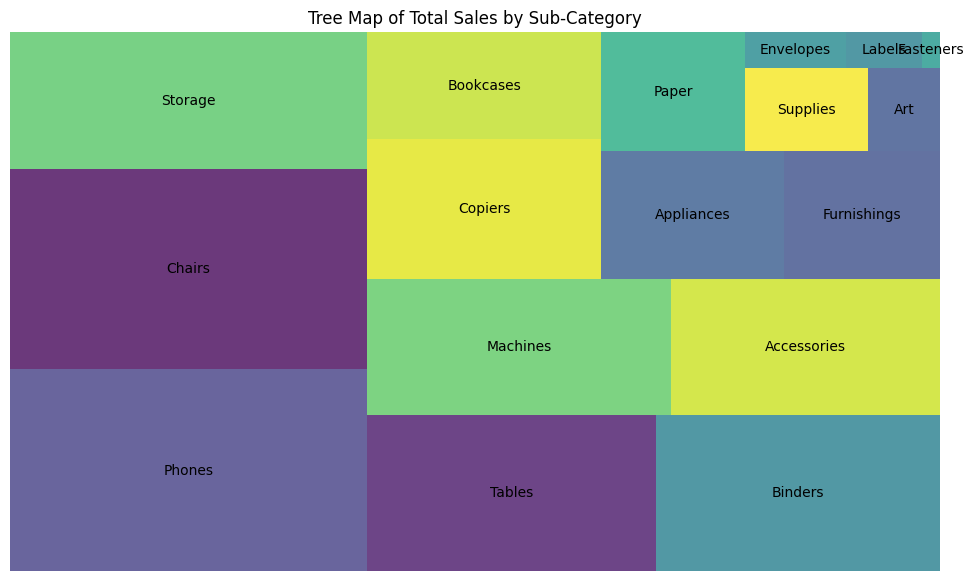

In [58]:
plt.figure(figsize=(12, 7))

squarify.plot(
    sizes=treemap_data.values,
    label=treemap_data.index,
    alpha=0.8
)

plt.axis('off')
plt.title("Tree Map of Total Sales by Sub-Category")

plt.show()